# Análisis modular del TP1

Este notebook ejecuta el flujo de análisis por celdas y es compatible con VS Code, Jupyter y Google Colab.

**Archivo de entrada:** `datos_TP1_2025.csv`

## 1. Crear el notebook y seleccionar el kernel

En VS Code o Colab, seleccioná un kernel de Python válido antes de ejecutar las celdas. Los resultados quedarán embebidos en este archivo `.ipynb`.

## 2. Instalar y validar dependencias

Ejecutá esta celda solo si el entorno no tiene `pandas` o `matplotlib` instalados. En Google Colab normalmente ya están disponibles.

In [109]:
pip install optbinning

You should consider upgrading via the '/Users/diegorojas/Documents/github projects/aa-tp-1/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [110]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from optbinning import OptimalBinning
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from scipy.stats import spearmanr
sys.path.append(str(Path.cwd().parent))
from functions.utils import *
from functions.eda import *

## 3. Cargar los datos

La ruta relativa funciona tanto en la carpeta local del proyecto como después de subir el archivo a Colab.

In [111]:
OUTPUT_DIR = Path("../outputs")

dataset = cargar_pickle("../outputs/dataset_cleaned.pkl")
dataset.head()

Archivo pickle cargado desde: /Users/diegorojas/Documents/github projects/aa-tp-1/outputs/dataset_cleaned.pkl


,Estudios_máximos_antes_de_la_inscripción,estado_civil,modo_aplicacion,sexo,desplazado,target,carrera,asistencia,cualificacion_promedio,puntaje_ingreso,...,promedio_uc_inscritos_semestres,promedio_uc_aprobadas_semestres,promedio_cant_evaluaciones_semestres,ratio_aprobadas_inscritas,ingresos_padre_nivel,ingresos_madre_nivel,ingresos_familia_nivel,demanda_cog_padre_nivel,demanda_cog_madre_nivel,demanda_cog_familia_nivel
0,Educación Secundaria,Soltero,Acceso General,Femenino,Sí,Graduado,Turismo,Diurna,65,61,...,6.0,5.5,7.0,0.916667,1,1,1.0,1,1,1.0
1,Educación Secundaria,Soltero,Acceso por Normativa Específica,Femenino,No,Desertor,Enfermería,Diurna,67,58,...,7.0,0.0,12.5,0.000000,1,1,1.0,1,1,1.0
2,Educación Secundaria,Soltero,Acceso General,Femenino,Sí,En Curso,Gestión,Diurna,64,62,...,5.0,2.5,8.5,0.500000,1,3,2.0,1,3,2.0
3,Educación Secundaria,Soltero,Acceso General,Femenino,Sí,En Curso,Enfermería,Diurna,67,54,...,7.0,4.0,8.5,0.571429,3,3,3.0,3,3,3.0
4,Educación Secundaria,Soltero,Acceso General,Femenino,Sí,En Curso,Publicidad y Marketing,Diurna,68,62,...,6.0,6.0,7.5,1.000000,5,1,3.0,5,1,3.0


In [112]:
num_columns = ['cualificacion_promedio', 'puntaje_ingreso', 'edad_inscripcion',
       'es_masculino', 'es_desplazado', 'es_asistencia_diurna', 'es_deudor',
       'es_moroso', 'es_becado', 'es_estudiante_internacional',
       'tiene_necesidades_educativas_especiales', 'promedio_notas_semestres',
       'promedio_uc_inscritos_semestres', 'promedio_uc_aprobadas_semestres',
       'promedio_cant_evaluaciones_semestres', 'ratio_aprobadas_inscritas',
       'ingresos_familia_nivel', 'demanda_cog_familia_nivel']

In [113]:
estadisticas_numericas = calcular_estadisticas_numericas(dataset, num_columns)
estadisticas_numericas

,N,N Miss,Missing,Zeros,Positivos,Negativos,min,max,mean,p_0.01,p_0.05,p_0.25,p_0.5,p_0.75,p_0.95,p_0.99,std,Coeff of Variation
cualificacion_promedio,50000,0,0.0,0,50000,0,48.0,95.0,66.256820,51.99,58.0,62.0,67.000000,70.0,75.0,80.0,5.518564,0.083291
puntaje_ingreso,50000,0,0.0,0,50000,0,48.0,95.0,62.671620,49.00,52.0,59.0,62.000000,66.0,75.0,80.0,6.279323,0.100194
edad_inscripcion,50000,0,0.0,0,50000,0,17.0,70.0,22.278760,18.00,18.0,18.0,19.000000,23.0,38.0,49.0,6.898876,0.309662
es_masculino,50000,0,0.0,34240,15760,0,0.0,1.0,0.315200,0.00,0.0,0.0,0.000000,1.0,1.0,1.0,0.464600,1.473985
es_desplazado,50000,0,0.0,21452,28548,0,0.0,1.0,0.570960,0.00,0.0,0.0,1.000000,1.0,1.0,1.0,0.494944,0.866863
es_asistencia_diurna,50000,0,0.0,4244,45756,0,0.0,1.0,0.915120,0.00,0.0,1.0,1.000000,1.0,1.0,1.0,0.278706,0.304557
es_deudor,50000,0,0.0,46424,3576,0,0.0,1.0,0.071520,0.00,0.0,0.0,0.000000,0.0,1.0,1.0,0.257694,3.603105
es_moroso,50000,0,0.0,44639,5361,0,0.0,1.0,0.107220,0.00,0.0,0.0,0.000000,0.0,1.0,1.0,0.309396,2.885617
es_becado,50000,0,0.0,37622,12378,0,0.0,1.0,0.247560,0.00,0.0,0.0,0.000000,0.0,1.0,1.0,0.431599,1.743412
es_estudiante_internacional,50000,0,0.0,49671,329,0,0.0,1.0,0.006580,0.00,0.0,0.0,0.000000,0.0,0.0,0.0,0.080851,12.287339


In [114]:
cat_columns = ['Estudios_máximos_antes_de_la_inscripción', 'estado_civil', 'modo_aplicacion', 'macro_categoria_carrera']
estadisticas_categoricas = calcular_estadisticas_categoricas(dataset, cat_columns)
estadisticas_categoricas

,Missing,Niveles,Moda,Frec_Moda,Largo
Variable,,,,,
Estudios_máximos_antes_de_la_inscripción,0,5,Educación Secundaria,43950,50000
estado_civil,0,6,Soltero,45861,50000
modo_aplicacion,0,4,Acceso General,34694,50000
macro_categoria_carrera,0,6,"Comunicación, marketing y diseño",12490,50000


## 4. Correlación entre variables

La siguiente función calcula la matriz de correlación de las variables numéricas y puede mostrarla como mapa de calor.


In [115]:
variables_to_corr = [
       'es_masculino', 'es_desplazado', 'es_asistencia_diurna', 'es_deudor',
       'es_moroso', 'es_becado', 'es_estudiante_internacional',
       'tiene_necesidades_educativas_especiales',
       'uc_inscritos_primer_semestre', 'cant_eval_primer_semestre',
       'uc_aprobadas_primer_semestre', 'nota_promedio_primer_semestre',
       'uc_inscritos_segundo_semestre', 'cant_eval_segundo_semestre',
       'uc_aprobadas_segundo_semestre', 'nota_promedio_segundo_semestre',
       'ratio_aprobadas_inscritas', 'promedio_notas_semestres', 'promedio_cant_evaluaciones_semestres',
       'ingresos_familia_nivel', 'demanda_cog_familia_nivel'
]

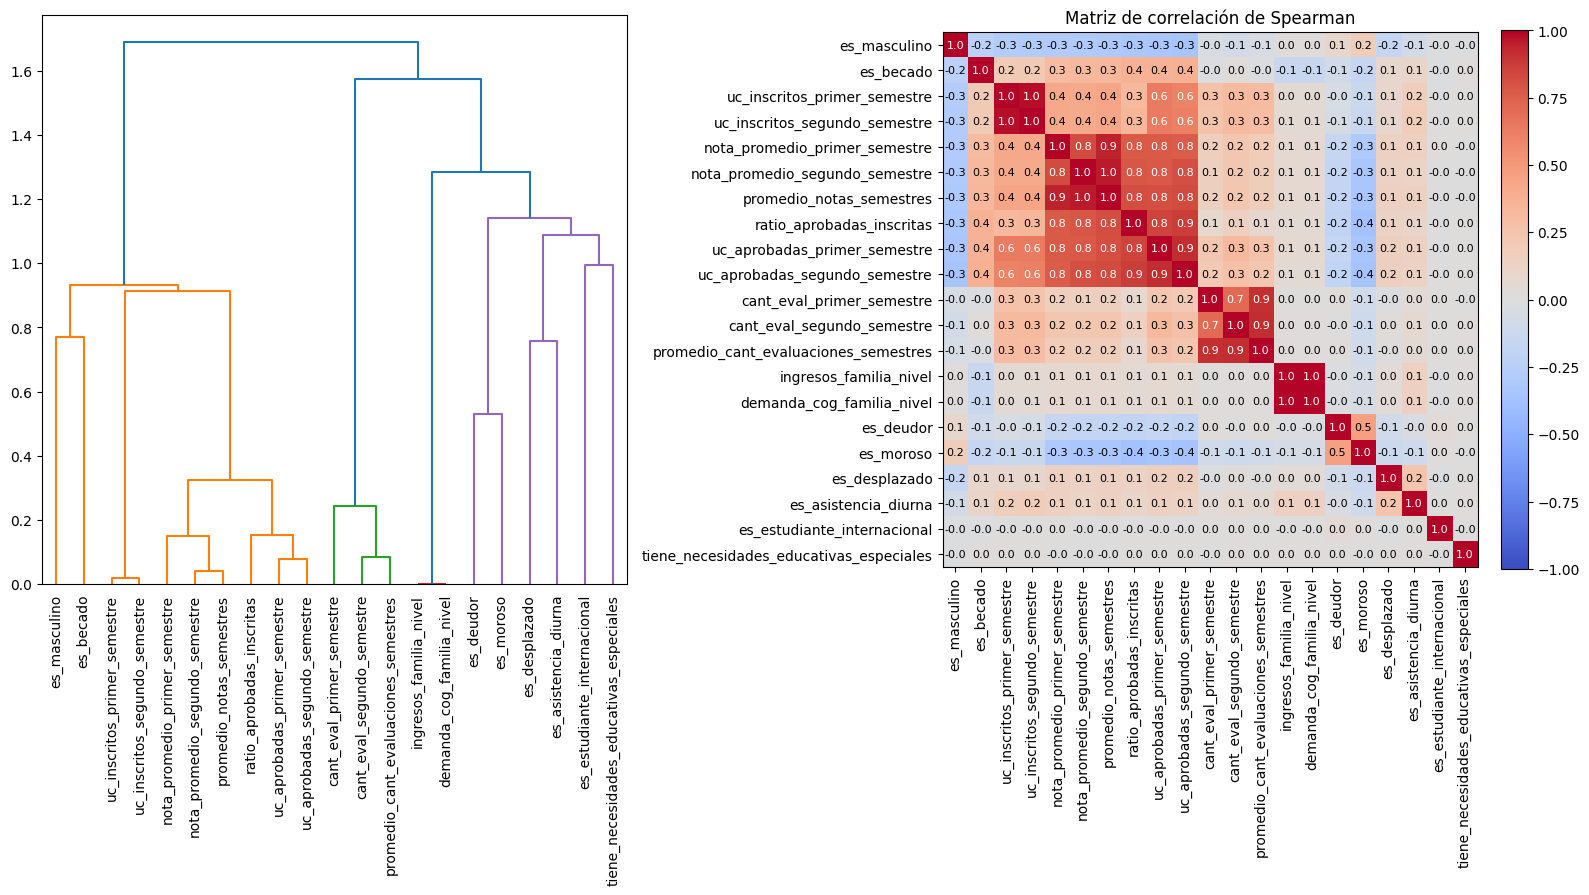

In [116]:
fig, (ax1, ax2) = graficar_clustering_correlacion(
    dataset,
    variables_to_corr,
)
plt.show()

### Frecuencia para variable target

In [117]:
dataset["target_num"] = dataset["target"].map({"Graduado": 0, "Desertor": 1, "En Curso": 2})
dataset_binario = dataset[dataset["target"].isin(["Desertor", "Graduado"])].copy()
dataset_binario["es_desercion"] = dataset_binario["target"].map({"Graduado": 0, "Desertor": 1})

In [118]:
calcular_frecuencias(dataset, "target")

,Frecuencia,Frecuencia relativa (%)
target,,
Graduado,23707,47.414
Desertor,16529,33.058
En Curso,9764,19.528


### Gráficos para variables númericas

In [119]:
#graficar_barras_apiladas(dataset, "target", ['Estudios_máximos_antes_de_la_inscripción', 'estado_civil',
#    'modo_aplicacion', 'sexo', 'desplazado', 'carrera', 'macro_categoria_carrera',
#    'asistencia', 'necesidades_educativas_especiales', 'tiene_deuda', 'matricula_al_dia',
#    'posee_beca','estudiante_internacional'])

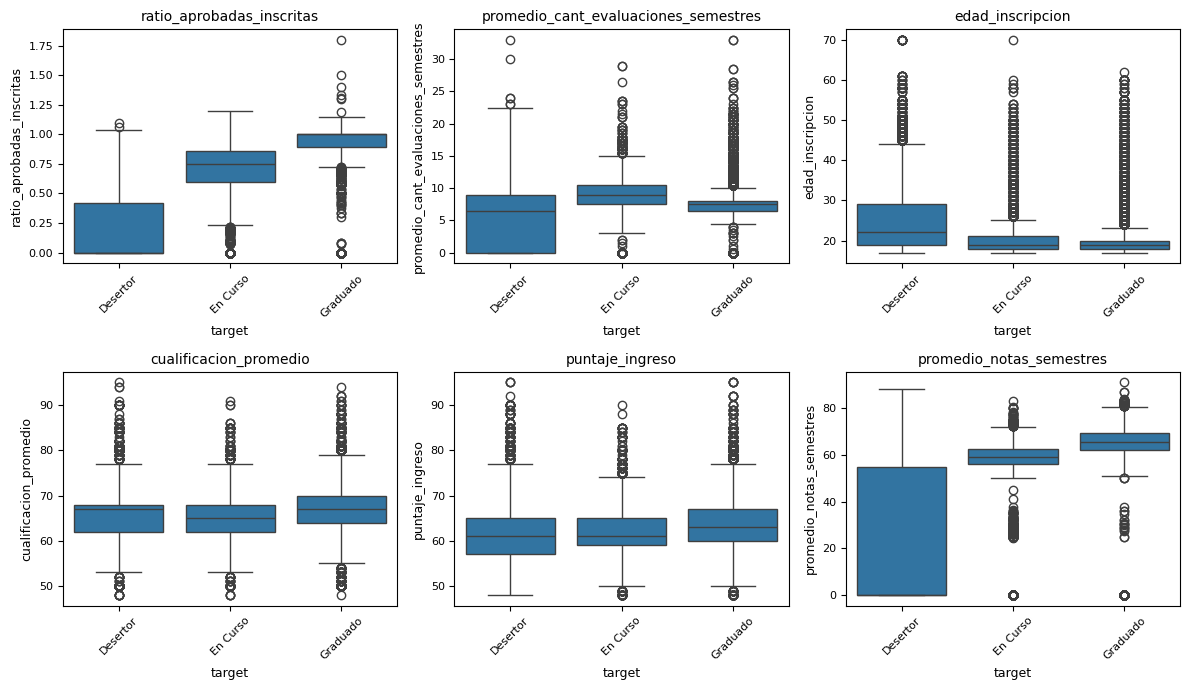

In [120]:
graficar_boxplot(dataset, "target", ['ratio_aprobadas_inscritas',
                    'promedio_cant_evaluaciones_semestres', 'edad_inscripcion', 'cualificacion_promedio', 'puntaje_ingreso', 'promedio_notas_semestres'])

## 5. Calcula de Information Value (IV)

Usamos como target la variable a predecir **es_desercion** que ya ha sido binarizada y toma los valores de 0 para los graduados y 1 para los desertores.

In [121]:
variables_to_iv = [
    'Estudios_máximos_antes_de_la_inscripción', 'estado_civil',
    'modo_aplicacion', 'sexo', 'desplazado', 'carrera',
    'asistencia', 'cualificacion_promedio', 'puntaje_ingreso',
    'necesidades_educativas_especiales', 'tiene_deuda', 'matricula_al_dia',
    'posee_beca', 'edad_inscripcion', 'estudiante_internacional',
    'promedio_notas_semestres', 'ratio_aprobadas_inscritas', 'promedio_cant_evaluaciones_semestres', 
    'demanda_cog_familia_nivel', 'ingresos_familia_nivel'
]

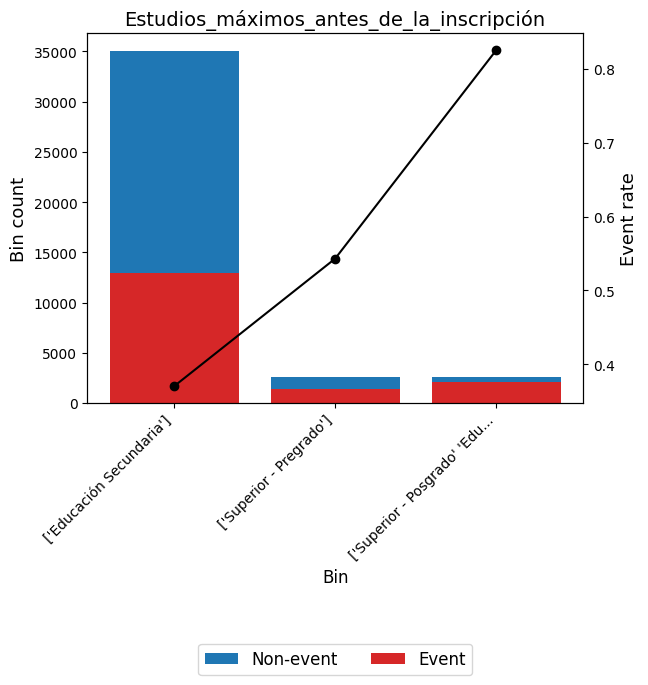

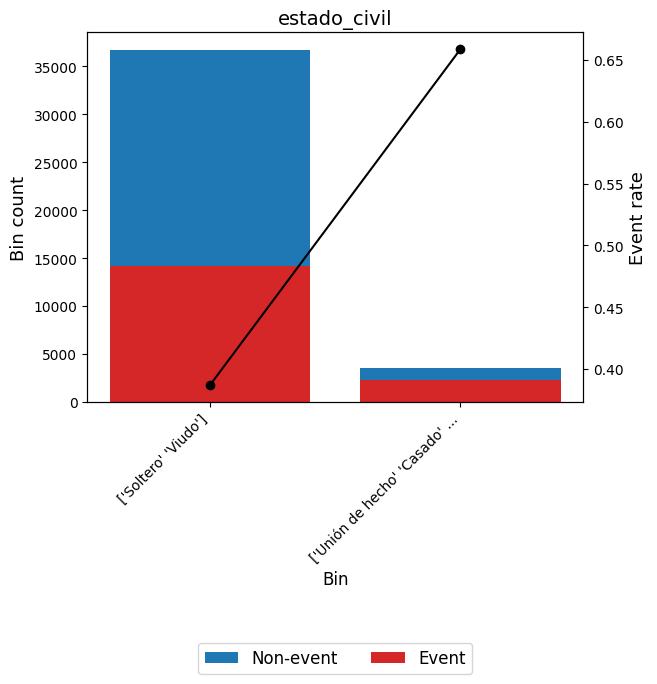

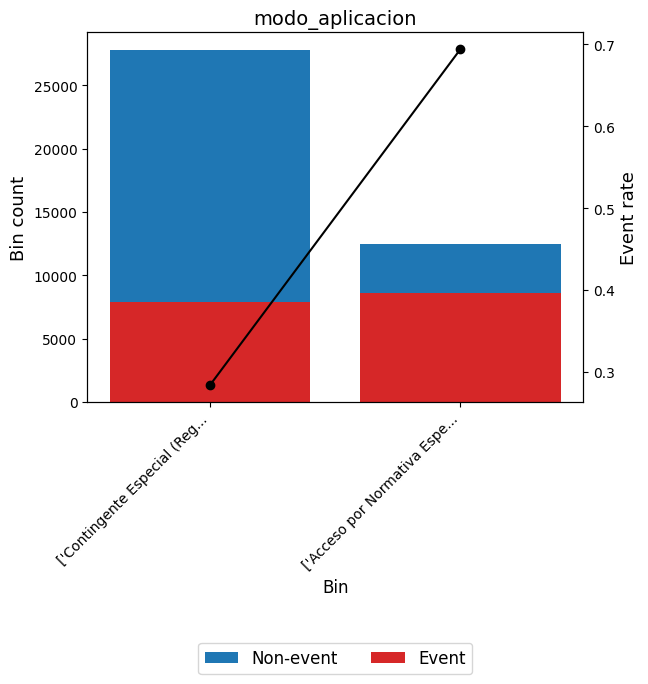

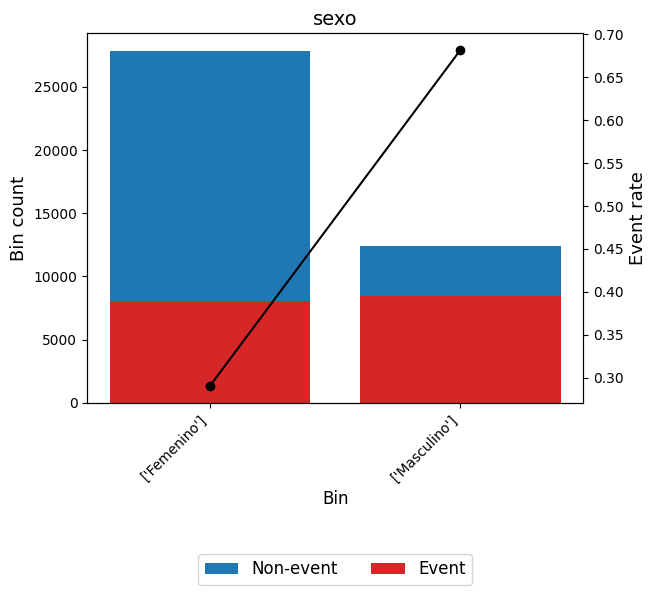

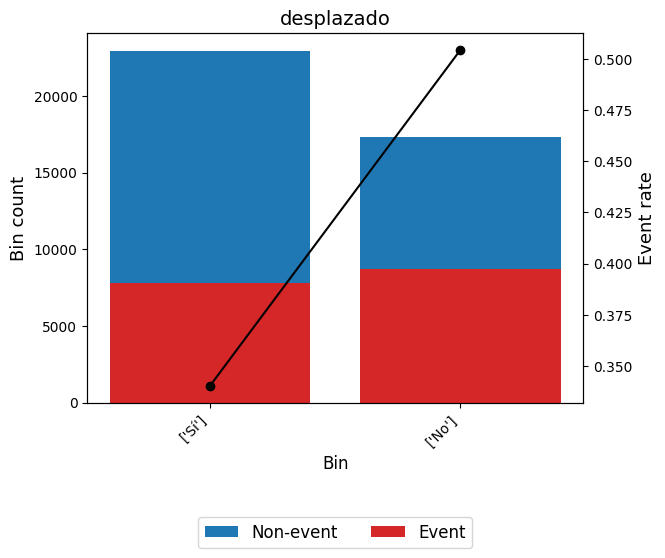

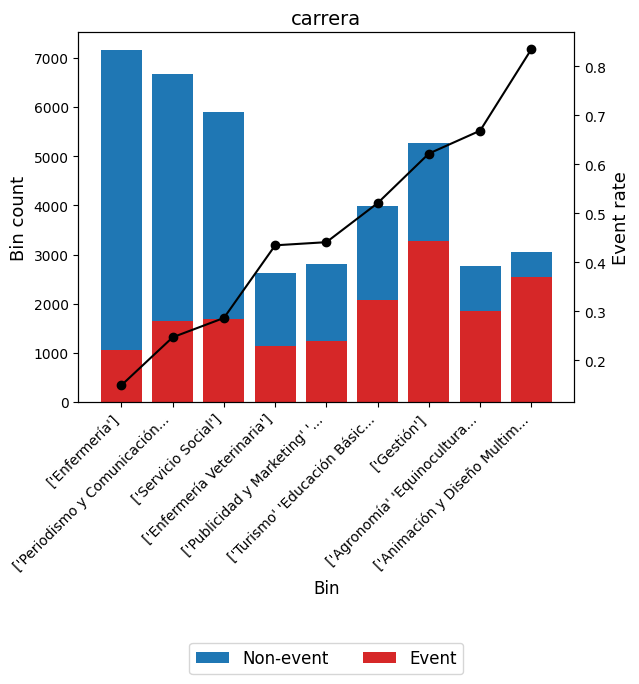

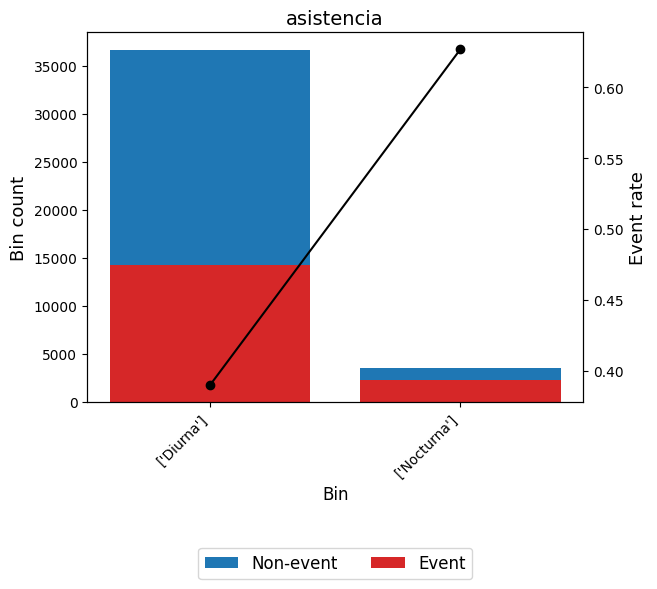

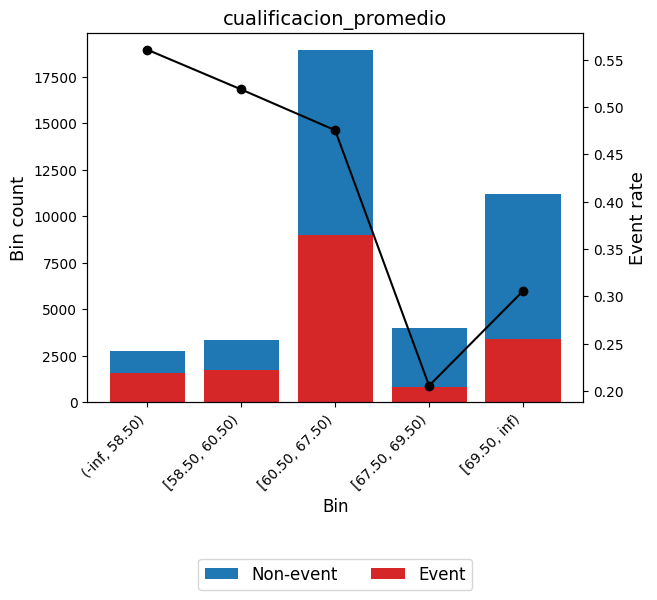

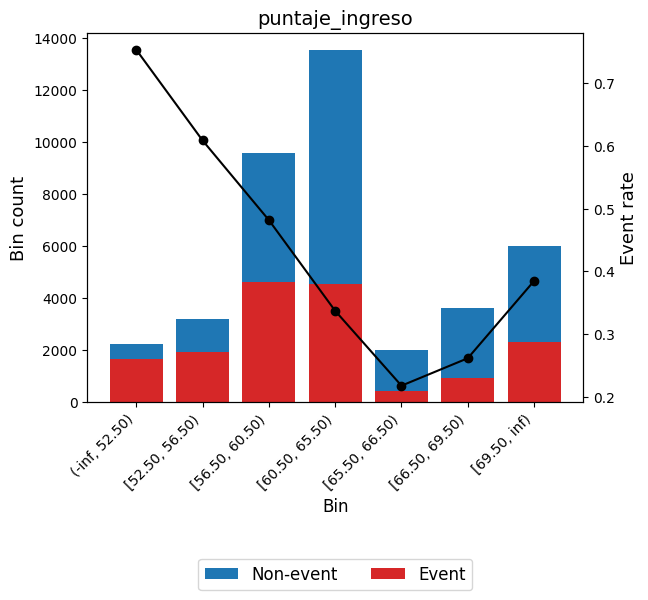

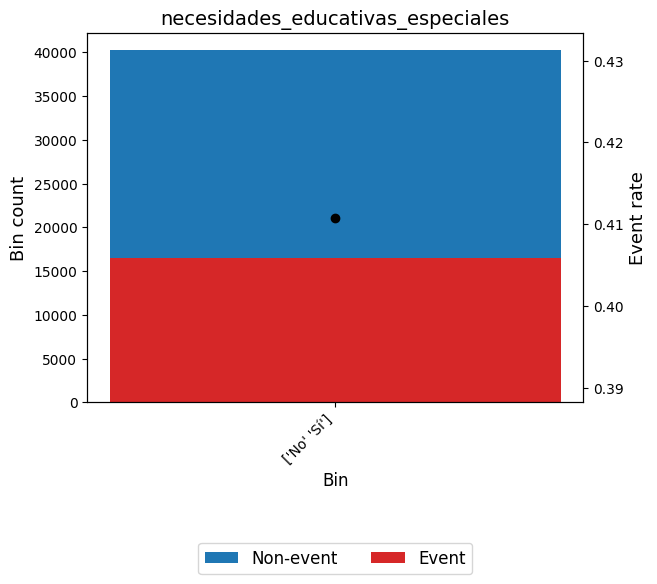

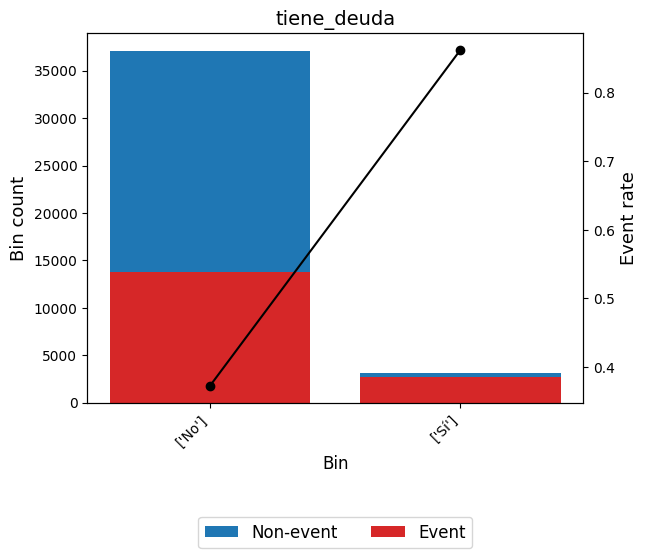

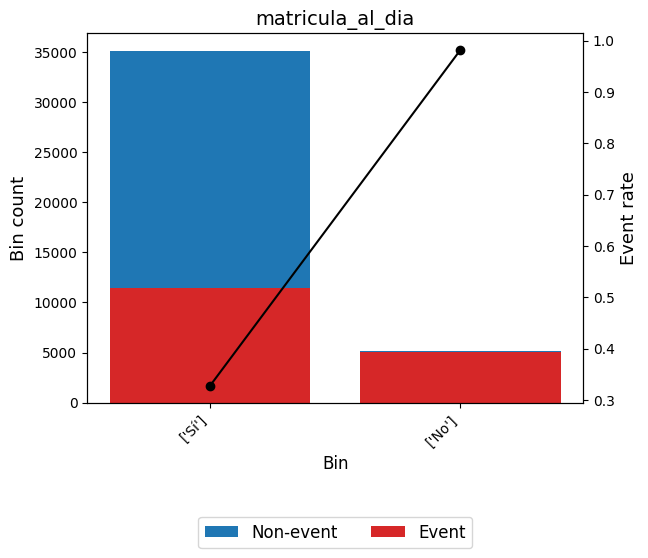

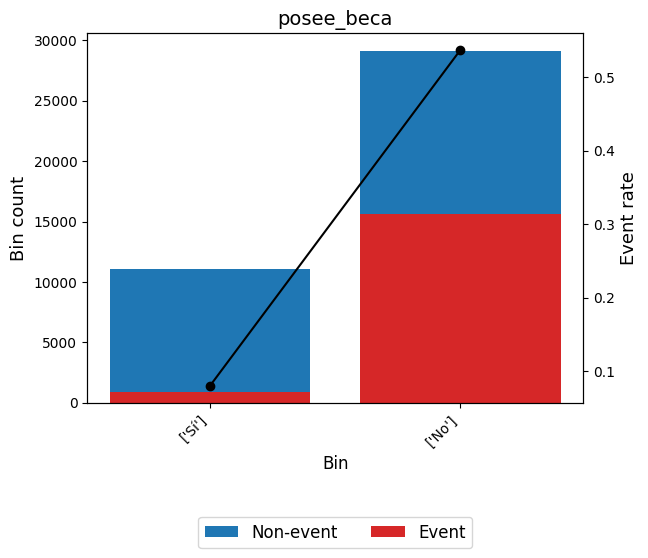

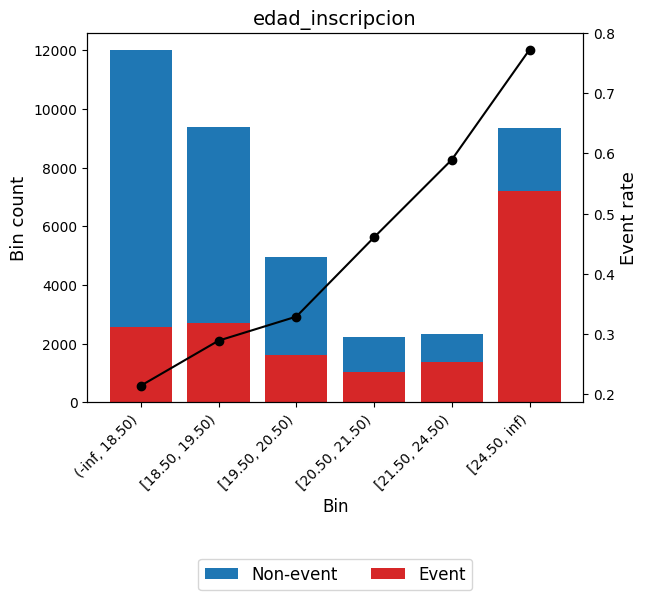

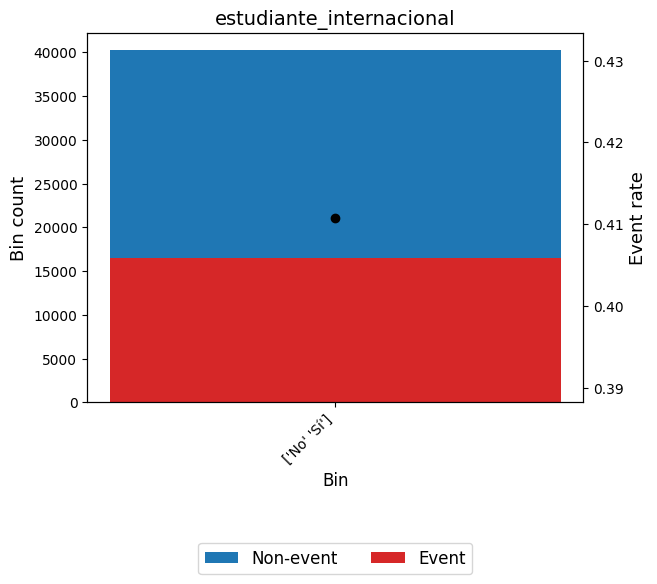

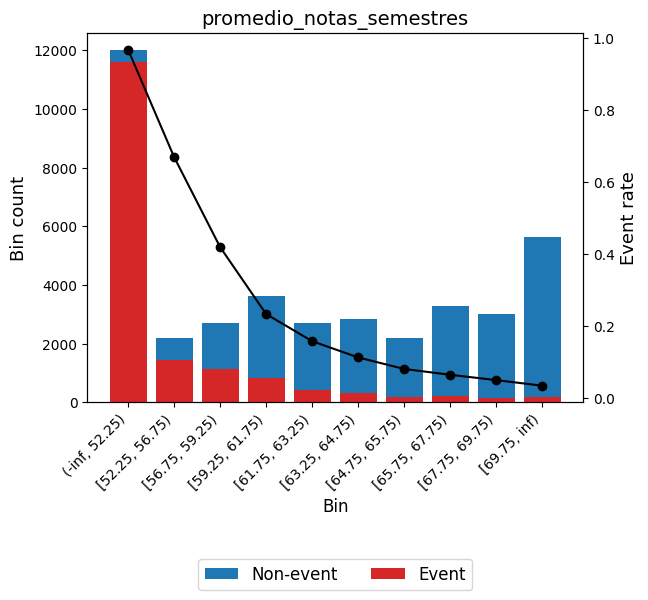

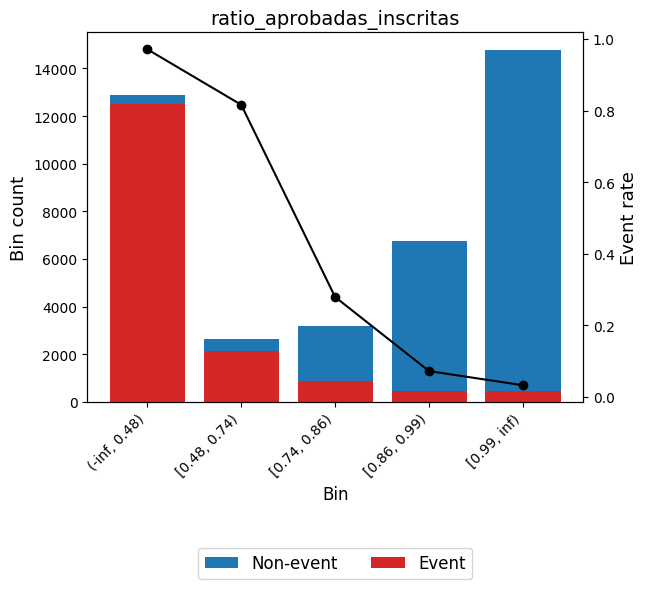

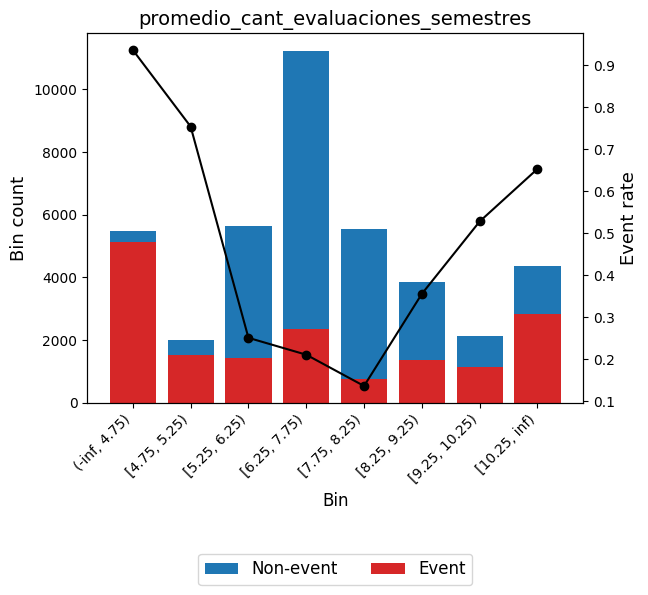

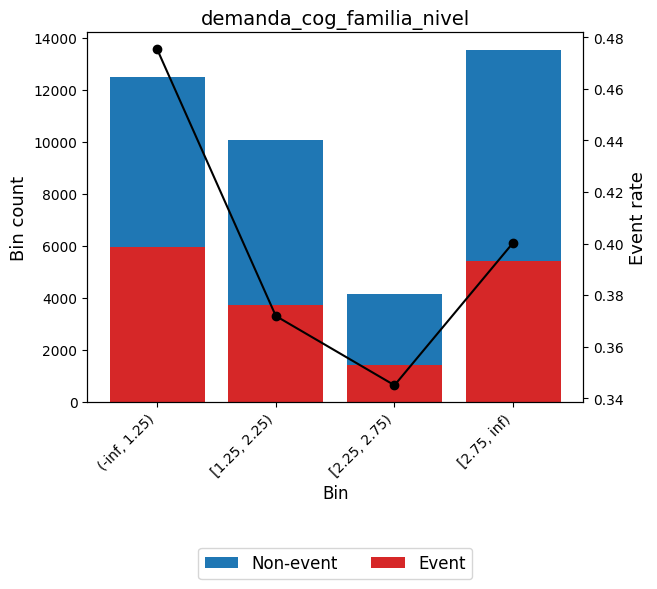

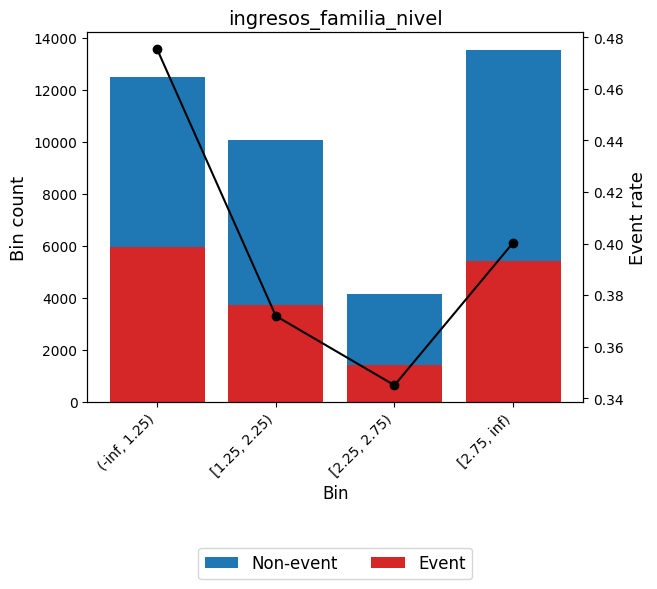

,variable,tipo,iv
0,ratio_aprobadas_inscritas,numerical,5.376047
1,promedio_notas_semestres,numerical,4.334500
2,promedio_cant_evaluaciones_semestres,numerical,1.649713
3,matricula_al_dia,categorical,1.420947
4,posee_beca,categorical,0.973717
5,edad_inscripcion,numerical,0.886453
6,carrera,categorical,0.852064
7,modo_aplicacion,categorical,0.632059
8,sexo,categorical,0.570179
9,tiene_deuda,categorical,0.342516


In [122]:
calcular_bivariado_iv(dataset_binario, 'es_desercion', variables_to_iv)

In [123]:
guardar_dataframe_pickle(dataset_binario, "dataset_binario", OUTPUT_DIR)

DataFrame guardado en: /Users/diegorojas/Documents/github projects/aa-tp-1/outputs/dataset_binario.pkl


PosixPath('../outputs/dataset_binario.pkl')

In [124]:
guardar_dataframe_pickle(dataset, "dataset_multiclase", OUTPUT_DIR)

DataFrame guardado en: /Users/diegorojas/Documents/github projects/aa-tp-1/outputs/dataset_multiclase.pkl


PosixPath('../outputs/dataset_multiclase.pkl')